In [265]:
import signal_gen_toolbox as sgt

import importlib
importlib.reload(sgt)

fn_yaml = "config.yaml"


In [266]:
config = sgt.load_config(fn_yaml)



{'signals': {'sig1': {'display_name': 'signal_1',
                      'units': 'F',
                      'min_value': 0,
                      'max_value': 100,
                      'max_rate_of_change': 10,
                      'no_change_probability': 0.3,
                      'plot_color': 'red'},
             'sig2': {'display_name': 'signal_2',
                      'units': 'F',
                      'min_value': 0,
                      'max_value': 200,
                      'max_rate_of_change': 10,
                      'no_change_probability': 0.3,
                      'plot_color': 'purple'},
             'sig3': {'display_name': 'signal_3',
                      'units': 'F',
                      'min_value': 0,
                      'max_value': 300,
                      'max_rate_of_change': 100,
                      'no_change_probability': 0.3,
                      'plot_color': 'blue'}},
 'derived_signals': {'sig4': {'display_name': 'signal_4',
            

In [267]:
N_loadcases = 100

import pandas as pd


df_all = pd.DataFrame(index = range(N_loadcases), columns = ['loadcase_name', 'df_signals', 'df_parameters'])

for i in range(N_loadcases):
    loadcase_name = f"ramp_{i+1:05d}"
    df_signals, df_parameters = sgt.generate_ramp_loadcase(config)
    #sgt.plot_loadcase(df_signals, config, loadcase_name = loadcase_name)

    df_all.loc[i,  ['loadcase_name', 'df_signals', 'df_parameters']] = [loadcase_name, df_signals, df_parameters]

print(df_all.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   loadcase_name  100 non-null    object
 1   df_signals     100 non-null    object
 2   df_parameters  100 non-null    object
dtypes: object(3)
memory usage: 2.5+ KB
None


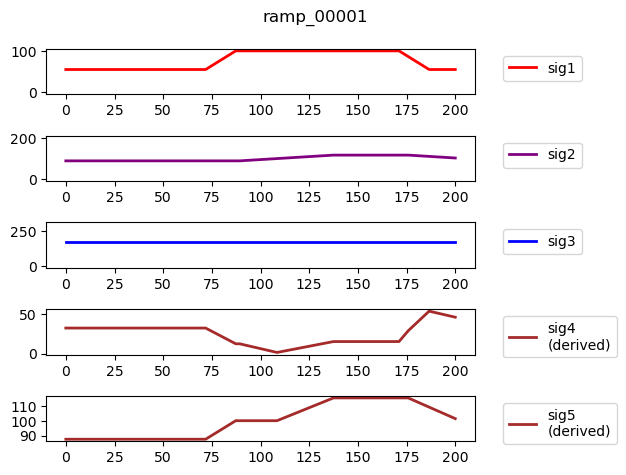

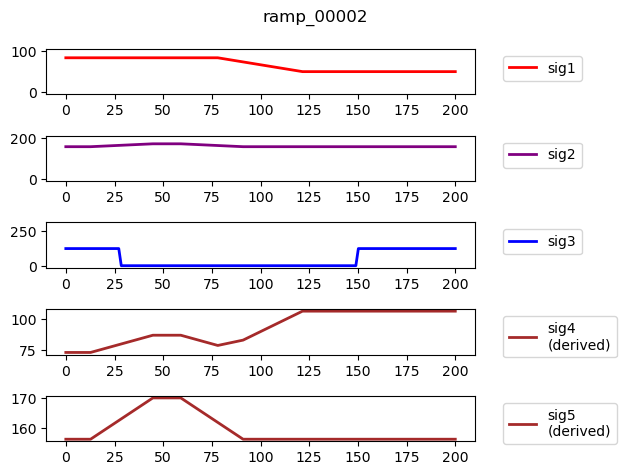

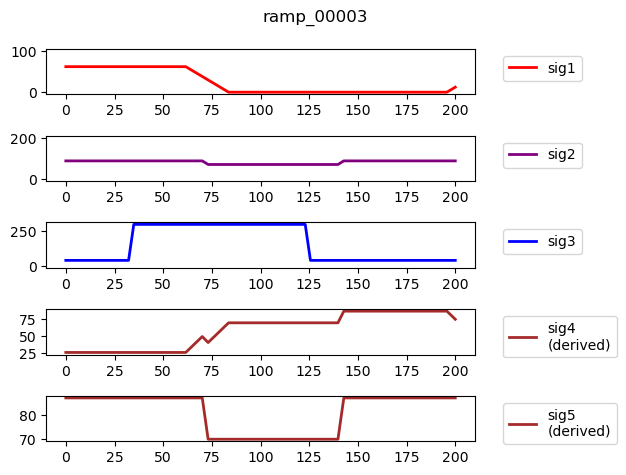

In [268]:
for i in range(3):
    loadcase_name = df_all.loc[i, 'loadcase_name']
    df_signals = df_all.loc[i, 'df_signals']
    sgt.plot_loadcase(df_signals, config, loadcase_name = loadcase_name)